In [1]:
import pandas as pd

data = {
    "Order_ID": [101, 102, 103, 104, 105, 106],
    "Product": ["Laptop", "Mobile", "Laptop", "Tablet", "Mobile", "Laptop"],
    "Quantity": [1, 2, 1, 3, 1, 2],
    "Price": [60000, 20000, 60000, 15000, 20000, 60000],
    "Date": ["2024-01-10", "2024-01-15", "2024-02-05", "2024-02-20", "2024-03-12", "2024-03-25"]
}

df = pd.DataFrame(data)
df


,Order_ID,Product,Quantity,Price,Date
0,101,Laptop,1,60000,2024-01-10
1,102,Mobile,2,20000,2024-01-15
2,103,Laptop,1,60000,2024-02-05
3,104,Tablet,3,15000,2024-02-20
4,105,Mobile,1,20000,2024-03-12
5,106,Laptop,2,60000,2024-03-25


In [2]:
df["Date"] = pd.to_datetime(df["Date"])
df["Total_Sales"] = df["Quantity"] * df["Price"]

df


,Order_ID,Product,Quantity,Price,Date,Total_Sales
0,101,Laptop,1,60000,2024-01-10,60000
1,102,Mobile,2,20000,2024-01-15,40000
2,103,Laptop,1,60000,2024-02-05,60000
3,104,Tablet,3,15000,2024-02-20,45000
4,105,Mobile,1,20000,2024-03-12,20000
5,106,Laptop,2,60000,2024-03-25,120000


In [3]:
top_products = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)
top_products


Product
Laptop    240000
Mobile     60000
Tablet     45000
Name: Total_Sales, dtype: int64

In [4]:
df["Month"] = df["Date"].dt.month

monthly_sales = df.groupby("Month")["Total_Sales"].sum()
monthly_sales


Month
1    100000
2    105000
3    140000
Name: Total_Sales, dtype: int64

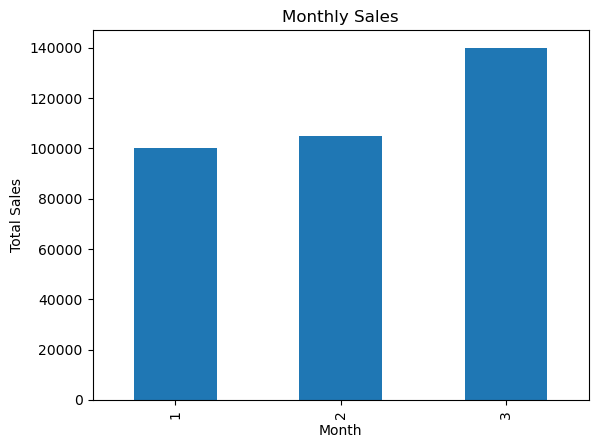

In [5]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="bar")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


In [6]:
df.to_excel("Cleaned_Sales_Data.xlsx", index=False)


In [7]:
import pandas as pd

df = pd.read_excel("sales.xlsx")
df.head()


,Order_ID,Product,Quantity,Price,Date
0,101,Laptop,1,60000,2024-01-10
1,102,Mobile,2,20000,2024-01-15
2,103,Laptop,1,60000,2024-02-05
3,104,Tablet,3,15000,2024-02-20
4,105,Mobile,1,20000,2024-03-12


In [8]:
df.isnull().sum()


Order_ID    0
Product     0
Quantity    0
Price       0
Date        0
dtype: int64

In [9]:
df = df.dropna()


In [10]:
df["Date"] = pd.to_datetime(df["Date"])
df["Total_Sales"] = df["Quantity"] * df["Price"]


In [11]:
top5 = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False).head(5)
top5


Product
Laptop    240000
Mobile     60000
Tablet     45000
Name: Total_Sales, dtype: int64

In [12]:
df["Month"] = df["Date"].dt.month_name()

monthly = df.groupby("Month")["Total_Sales"].sum()
monthly


Month
February    105000
January     100000
March       140000
Name: Total_Sales, dtype: int64

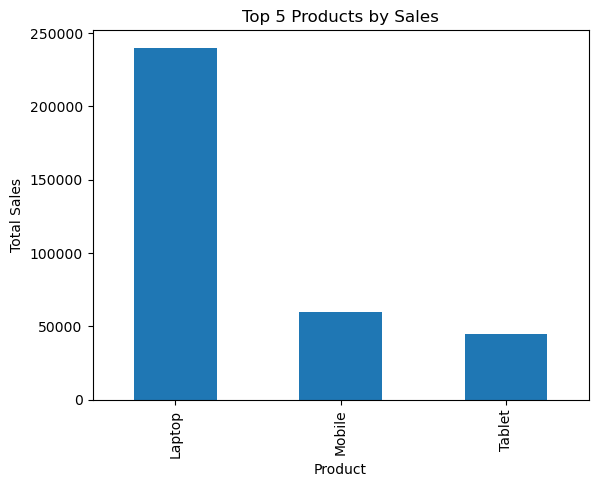

In [13]:
import matplotlib.pyplot as plt

top5.plot(kind="bar")
plt.title("Top 5 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.show()


In [14]:
df["Cost_Price"] = df["Price"] * 0.7
df["Profit"] = df["Total_Sales"] - (df["Cost_Price"] * df["Quantity"])

df[["Product", "Profit"]].head()


,Product,Profit
0,Laptop,18000.0
1,Mobile,12000.0
2,Laptop,18000.0
3,Tablet,13500.0
4,Mobile,6000.0


In [15]:
df.to_excel("Final_Sales_Analysis.xlsx", index=False)
